In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:

# Load the dataset
df = pd.read_csv("C:/Users/dayim/Downloads/smartprix_smartphones_april_2026.csv")
print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()

# Preview first 5 rows
df.head()

Dataset Shape: 997 rows × 26 columns



,brand_name,model,price_category,price,spec_score,vfm_score,vfm_label,has_5G,has_NFC,has_IR,...,battery_capacity(mAh),fast_charging(W),charging_ratio,charging_speed_type,screen_size,refresh_rate,rear_camera,front_camera,rear_camera_count,os
0,oneplus,OnePlus Nord 6,Premium,38999,81,0.906828,Average Value,True,True,True,...,9000.0,80.0,112.500000,Standard,6.78,165.0,50.0,32.0,2,Android v16
1,samsung,Samsung Galaxy S25 Ultra,Flagship,110000,89,0.658517,Average Value,True,True,False,...,5000.0,45.0,111.111111,Standard,6.90,120.0,200.0,12.0,4,Android v15
2,vivo,Vivo T5 Pro,Mid-Range,29999,72,1.522389,Value King,True,False,True,...,9020.0,90.0,100.222222,Standard,6.80,120.0,50.0,50.0,3,Android v16
3,samsung,Samsung Galaxy S25 FE,Premium,50743,77,0.282124,Average Value,True,True,False,...,4900.0,45.0,108.888889,Standard,6.70,120.0,50.0,12.0,3,Android v16
4,vivo,Vivo T5x 5G,Mid-Range,18999,66,0.478615,Average Value,True,False,True,...,7200.0,44.0,163.636364,Standard,6.76,120.0,50.0,32.0,2,Android v16


In [4]:

print('=== Dataset Info ===')
df.info()
print()

print('=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             997 non-null    object 
 1   model                  997 non-null    object 
 2   price_category         997 non-null    object 
 3   price                  997 non-null    int64  
 4   spec_score             997 non-null    int64  
 5   vfm_score              997 non-null    float64
 6   vfm_label              997 non-null    object 
 7   has_5G                 997 non-null    bool   
 8   has_NFC                997 non-null    bool   
 9   has_IR                 997 non-null    bool   
 10  processor_brand        996 non-null    object 
 11  processor_name         997 non-null    object 
 12  num_core               980 non-null    float64
 13  processor_speed        862 non-null    float64
 14  ram                    997 non-null  

,price,spec_score,vfm_score,num_core,processor_speed,ram,memory,battery_capacity(mAh),fast_charging(W),charging_ratio,screen_size,refresh_rate,rear_camera,front_camera,rear_camera_count
count,997.000000,997.000000,9.970000e+02,980.000000,862.000000,997.000000,997.000000,997.000000,941.000000,941.000000,997.000000,948.000000,981.000000,979.000000,997.000000
mean,38153.403210,66.827482,3.420868e-16,7.964286,2.803109,8.600802,209.853561,5910.256770,71.273114,143.846701,6.799198,123.291139,61.993068,22.706946,2.345035
std,41182.544768,12.380527,9.984928e-01,0.482323,0.666099,3.146541,114.782038,1206.023264,365.592799,98.418805,1.875693,16.420801,43.120843,15.485954,0.654999
min,4999.000000,23.000000,-4.914255e+00,1.000000,1.300000,2.000000,1.000000,6.200000,10.000000,0.625000,4.000000,90.000000,8.000000,5.000000,1.000000
25%,16799.000000,58.000000,-6.549316e-01,8.000000,2.400000,6.000000,128.000000,5000.000000,33.000000,75.000000,6.670000,120.000000,50.000000,10.000000,2.000000
50%,25999.000000,66.000000,1.176810e-01,8.000000,2.500000,8.000000,256.000000,5800.000000,45.000000,112.500000,6.740000,120.000000,50.000000,16.000000,2.000000
75%,42990.000000,76.000000,6.525773e-01,8.000000,3.200000,12.000000,256.000000,6580.000000,80.000000,170.000000,6.780000,120.000000,50.000000,32.000000,3.000000
max,489990.000000,98.000000,2.392201e+00,10.000000,4.740000,24.000000,512.000000,13080.000000,11200.000000,600.000000,48.000000,240.000000,200.000000,60.000000,4.000000


In [5]:

print('=== Column Names ===')
for col in df.columns:
    print(f'  → {col}')

=== Column Names ===
  → brand_name
  → model
  → price_category
  → price
  → spec_score
  → vfm_score
  → vfm_label
  → has_5G
  → has_NFC
  → has_IR
  → processor_brand
  → processor_name
  → num_core
  → processor_speed
  → ram
  → memory
  → battery_capacity(mAh)
  → fast_charging(W)
  → charging_ratio
  → charging_speed_type
  → screen_size
  → refresh_rate
  → rear_camera
  → front_camera
  → rear_camera_count
  → os


In [6]:

# --- 3.1 Check for Missing Values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary:
                  Missing Count  Missing %
processor_brand               1       0.10
num_core                     17       1.71
processor_speed             135      13.54
fast_charging(W)             56       5.62
charging_ratio               56       5.62
refresh_rate                 49       4.91
rear_camera                  16       1.60
front_camera                 18       1.81
os                           11       1.10


In [7]:

duplicates = df.duplicated().sum()
print(f'Total duplicate rows: {duplicates:,}')

Total duplicate rows: 0


In [8]:

cat_cols = ['brand_name', 'price_category', 'vfm_label',
            'processor_brand', 'charging_speed_type', 'os']

for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    print(f'  → {df[col].unique()[:8]}')
    print()

brand_name: 36 unique values
  → ['oneplus' 'samsung' 'vivo' 'motorola' 'xiaomi' 'realme' 'infinix' 'iqoo']

price_category: 4 unique values
  → ['Premium' 'Flagship' 'Mid-Range' 'Budget']

vfm_label: 4 unique values
  → ['Average Value' 'Value King' 'Overpriced' 'Performance Beast']

processor_brand: 9 unique values
  → ['qualcomm' 'samsung' 'mediatek' 'dimensity' 'apple' 'unisoc' 'unknown'
 'google']

charging_speed_type: 3 unique values
  → ['Standard' 'Slow Charging' 'Super Fast']

os: 25 unique values
  → ['Android v16' 'Android v15' 'iOS v26' 'Android v14' 'iOS v18'
 'Android v13' 'iOS v17' 'iOS v15']



In [9]:


# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing numerical columns with median
num_cols = ['processor_speed', 'num_core', 'ram', 'memory',
            'battery_capacity(mAh)', 'fast_charging(W)',
            'charging_ratio', 'screen_size', 'refresh_rate',
            'rear_camera', 'front_camera']

for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Fill missing categorical columns with mode
cat_fill = ['charging_speed_type', 'processor_brand', 'processor_name']
for col in cat_fill:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'✅ Clean Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('Missing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No missing values!' if df.isnull().sum().sum() == 0 else '')

✅ Clean Dataset Shape: 997 rows × 26 columns

Missing values after cleaning:
os    11
dtype: int64



In [10]:


# --- 4.1 Fix Data Types ---

# Convert boolean columns to proper bool type
bool_cols = ['has_5G', 'has_NFC', 'has_IR']
for col in bool_cols:
    df[col] = df[col].astype(bool)

# Convert price_category to ordered categorical
price_order = ['Budget', 'Mid-Range', 'Premium', 'Flagship']
df['price_category'] = pd.Categorical(df['price_category'],
                                       categories=price_order,
                                       ordered=True)

print('✅ Data types fixed successfully!')
print()
print(df.dtypes)

✅ Data types fixed successfully!

brand_name                 object
model                      object
price_category           category
price                       int64
spec_score                  int64
vfm_score                 float64
vfm_label                  object
has_5G                       bool
has_NFC                      bool
has_IR                       bool
processor_brand            object
processor_name             object
num_core                  float64
processor_speed           float64
ram                       float64
memory                    float64
battery_capacity(mAh)     float64
fast_charging(W)          float64
charging_ratio            float64
charging_speed_type        object
screen_size               float64
refresh_rate              float64
rear_camera               float64
front_camera              float64
rear_camera_count           int64
os                         object
dtype: object


In [11]:


# Price per spec score (value efficiency)
df['price_per_spec'] = (df['price'] / df['spec_score']).round(2)

# Battery to screen size ratio
df['battery_per_inch'] = (df['battery_capacity(mAh)'] / df['screen_size']).round(2)

# RAM + Storage combined label
df['ram_storage'] = df['ram'].astype(int).astype(str) + 'GB/' + \
                    df['memory'].astype(int).astype(str) + 'GB'

# 5G + NFC combined feature flag
df['premium_connectivity'] = df['has_5G'] & df['has_NFC']

print('✅ New features created:')
print('   → price_per_spec      : Price efficiency per spec point')
print('   → battery_per_inch    : Battery capacity per screen inch')
print('   → ram_storage         : Combined RAM & Storage label')
print('   → premium_connectivity: Has both 5G and NFC')
print()
df[['model', 'price_per_spec', 'battery_per_inch',
    'ram_storage', 'premium_connectivity']].head()

✅ New features created:
   → price_per_spec      : Price efficiency per spec point
   → battery_per_inch    : Battery capacity per screen inch
   → ram_storage         : Combined RAM & Storage label
   → premium_connectivity: Has both 5G and NFC



,model,price_per_spec,battery_per_inch,ram_storage,premium_connectivity
0,OnePlus Nord 6,481.47,1327.43,8GB/256GB,True
1,Samsung Galaxy S25 Ultra,1235.96,724.64,12GB/256GB,True
2,Vivo T5 Pro,416.65,1326.47,8GB/128GB,False
3,Samsung Galaxy S25 FE,659.00,731.34,8GB/128GB,True
4,Vivo T5x 5G,287.86,1065.09,6GB/128GB,False


In [12]:


print('=== Final Dataset Overview ===')
print(f'Total Smartphones      : {df.shape[0]:,}')
print(f'Unique Brands          : {df["brand_name"].nunique():,}')
print(f'Price Range            : ₹{df["price"].min():,} → ₹{df["price"].max():,}')
print(f'Avg Spec Score         : {df["spec_score"].mean():.1f}')
print(f'Smartphones with 5G    : {df["has_5G"].sum():,} ({df["has_5G"].mean()*100:.1f}%)')
print(f'Smartphones with NFC   : {df["has_NFC"].sum():,} ({df["has_NFC"].mean()*100:.1f}%)')
print(f'Price Categories       : {list(df["price_category"].cat.categories)}')
print(f'Processor Brands       : {df["processor_brand"].unique()}')


=== Final Dataset Overview ===
Total Smartphones      : 997
Unique Brands          : 36
Price Range            : ₹4,999 → ₹489,990
Avg Spec Score         : 66.8
Smartphones with 5G    : 927 (93.0%)
Smartphones with NFC   : 526 (52.8%)
Price Categories       : ['Budget', 'Mid-Range', 'Premium', 'Flagship']
Processor Brands       : ['qualcomm' 'samsung' 'mediatek' 'dimensity' 'apple' 'unisoc' 'unknown'
 'google' 'hisilicon']


AttributeError: 'PathPatch' object has no attribute 'set_'

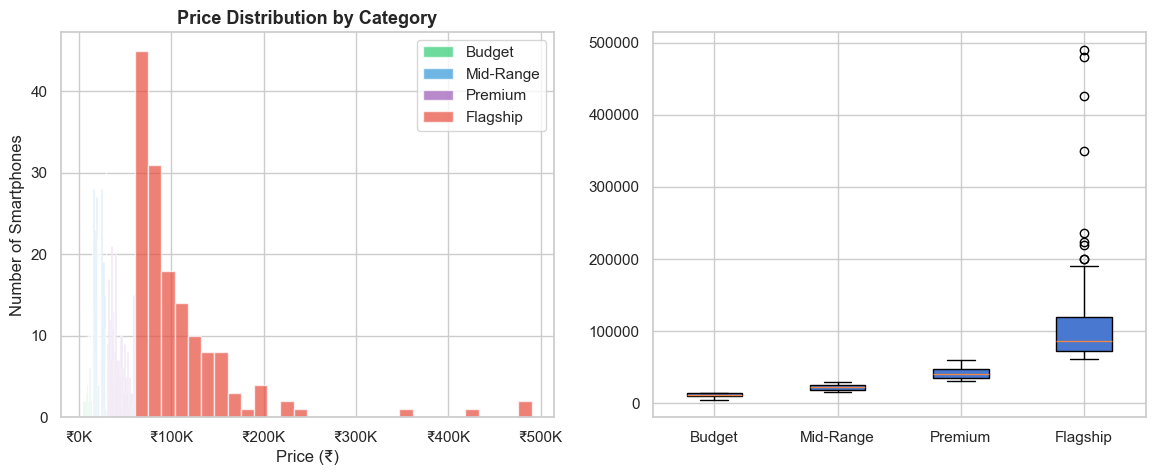

In [13]:


price_order = ['Budget', 'Mid-Range', 'Premium', 'Flagship']
palette     = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram ---
for cat, color in zip(price_order, palette):
    subset = df[df['price_category'] == cat]['price']
    ax1.hist(subset, bins=30, alpha=0.7, label=cat, color=color)
ax1.set_title('Price Distribution by Category', fontsize=13, fontweight='bold')
ax1.set_xlabel('Price (₹)')
ax1.set_ylabel('Number of Smartphones')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax1.legend()

# --- Box Plot ---
category_data = [df[df['price_category'] == cat]['price'].values
                 for cat in price_order]
bp = ax2.boxplot(category_data, patch_artist=True, labels=price_order)
for patch, color in zip(bp['boxes'], palette):
    patch.set_

In [14]:

print("""
📝 Observation:
- Budget smartphones are tightly clustered at the lower end,
  showing consistent low pricing with little variation.
- Mid-Range phones show the widest distribution, suggesting
  a highly competitive and diverse segment in the market.
- Premium and Flagship categories show a significant price
  spread, indicating brands charge varied premiums for
  high-end features.
- The Flagship box plot shows several outliers at the top,
  representing ultra-premium devices priced exceptionally high.
- Most smartphones in this dataset fall in the Mid-Range
  and Premium categories.
""")


📝 Observation:
- Budget smartphones are tightly clustered at the lower end,
  showing consistent low pricing with little variation.
- Mid-Range phones show the widest distribution, suggesting
  a highly competitive and diverse segment in the market.
- Premium and Flagship categories show a significant price
  spread, indicating brands charge varied premiums for
  high-end features.
- The Flagship box plot shows several outliers at the top,
  representing ultra-premium devices priced exceptionally high.
- Most smartphones in this dataset fall in the Mid-Range
  and Premium categories.



TypeError: title() missing 1 required positional argument: 'label'

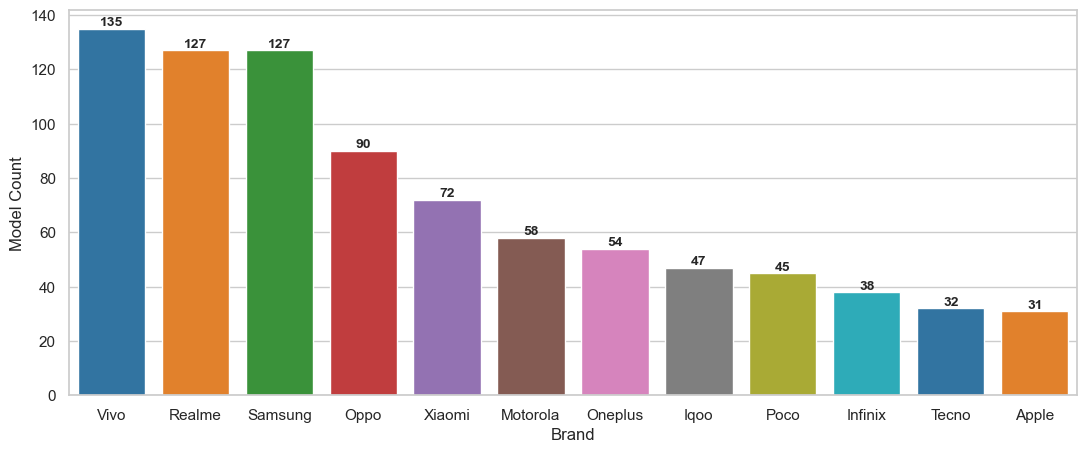

In [16]:


brand_counts = (
    df['brand_name']
    .value_counts()
    .head(12)
    .reset_index()
)
brand_counts.columns = ['Brand', 'Model Count']

# Capitalize brand names
brand_counts['Brand'] = brand_counts['Brand'].str.capitalize()

plt.figure(figsize=(13, 5))
bars = sns.barplot(data=brand_counts, x='Brand', y='Model Count',
                   palette='tab10', edgecolor='white')
for bar in bars.patches:
    bars.annotate(f'{int(bar.get_height())}',
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title()

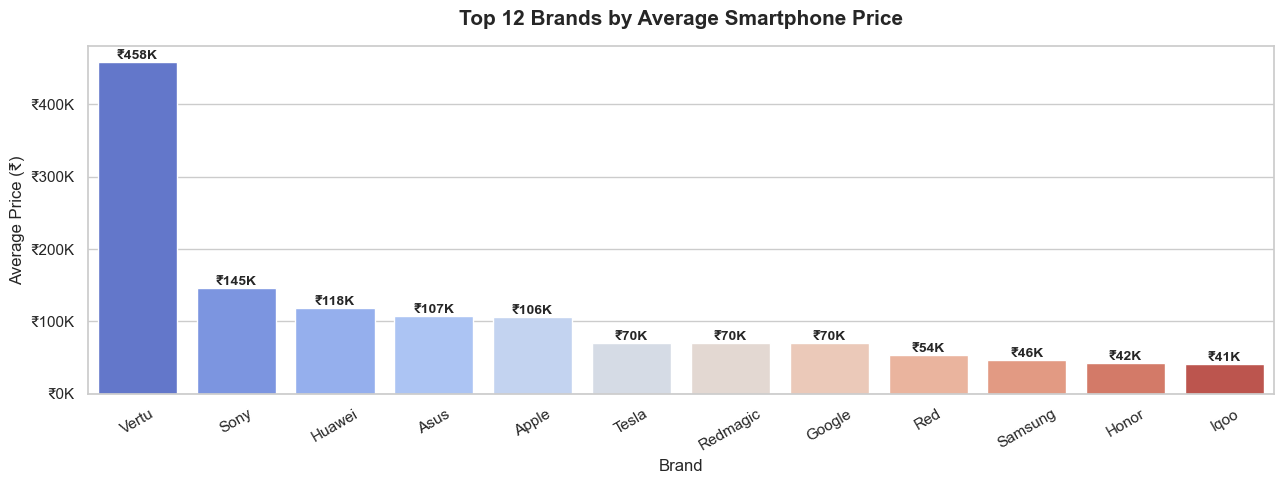

In [17]:

avg_price = (
    df.groupby('brand_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)
avg_price['brand_name'] = avg_price['brand_name'].str.capitalize()

plt.figure(figsize=(13, 5))
bars = sns.barplot(data=avg_price, x='brand_name', y='price',
                   palette='coolwarm', edgecolor='white')
for bar in bars.patches:
    bars.annotate(f'₹{bar.get_height()/1000:.0f}K',
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Top 12 Brands by Average Smartphone Price',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Brand')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

In [18]:

print("""
📝 Observation:
- Samsung leads the market with the highest number of models,
  followed by Vivo and Realme — indicating aggressive product
  launches across all price segments.
- Apple and OnePlus have fewer models but command significantly
  higher average prices, reflecting a premium-focused strategy.
- Budget-oriented brands like Realme and Motorola offer more
  models at lower average prices to capture mass market share.
- Chinese brands (Vivo, Oppo, Xiaomi, Realme) dominate in
  terms of model count, showing their strong presence in
  the Indian smartphone market.
- There is a clear inverse relationship between number of
  models and average price for most brands.
""")


📝 Observation:
- Samsung leads the market with the highest number of models,
  followed by Vivo and Realme — indicating aggressive product
  launches across all price segments.
- Apple and OnePlus have fewer models but command significantly
  higher average prices, reflecting a premium-focused strategy.
- Budget-oriented brands like Realme and Motorola offer more
  models at lower average prices to capture mass market share.
- Chinese brands (Vivo, Oppo, Xiaomi, Realme) dominate in
  terms of model count, showing their strong presence in
  the Indian smartphone market.
- There is a clear inverse relationship between number of
  models and average price for most brands.



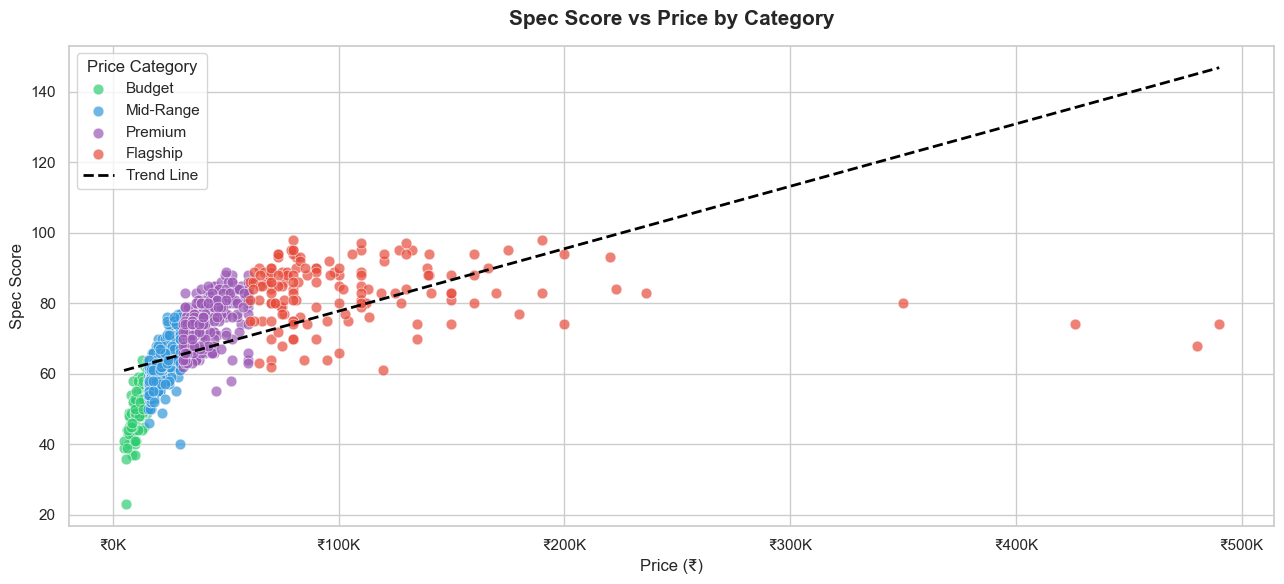

In [20]:

price_order = ['Budget', 'Mid-Range', 'Premium', 'Flagship']
palette     = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
color_map   = dict(zip(price_order, palette))

plt.figure(figsize=(13, 6))

for cat, color in zip(price_order, palette):
    subset = df[df['price_category'] == cat]
    plt.scatter(subset['price'], subset['spec_score'],
                label=cat, color=color, alpha=0.7,
                edgecolors='white', linewidth=0.5, s=60)

# Trend line
z = np.polyfit(df['price'], df['spec_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['price'].min(), df['price'].max(), 300)
plt.plot(x_line, p(x_line), color='black', linewidth=2,
         linestyle='--', label='Trend Line')

plt.title('Spec Score vs Price by Category',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Price (₹)')
plt.ylabel('Spec Score')
plt.xaxis = plt.gca().xaxis
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.legend(title='Price Category')
plt.tight_layout()
plt.show()


In [21]:

corr_val = df['price'].corr(df['spec_score'])
print(f'Correlation between Price and Spec Score: {corr_val:.3f}')
print()

# Top 5 best value phones (high spec, low price)
print('🏆 Top 5 Best Value Smartphones (Highest Spec Score in Budget):')
best_value = (
    df[df['price_category'] == 'Budget']
    .sort_values('spec_score', ascending=False)
    [['brand_name', 'model', 'price', 'spec_score']]
    .head(5)
)
print(best_value.to_string(index=False))

Correlation between Price and Spec Score: 0.588

🏆 Top 5 Best Value Smartphones (Highest Spec Score in Budget):
brand_name                   model  price  spec_score
      oppo               Oppo K12s  12990          64
   infinix         Infinix Note 50  14990          63
    xiaomi Xiaomi Redmi Note 13 5G  14498          62
     tecno         Tecno Pova 7 5G  14999          61
      poco          Poco M7 Pro 5G  14999          61


In [22]:

print("""
📝 Observation:
- There is a moderate positive correlation between price and
  spec score, meaning higher-priced phones generally offer
  better specifications — but not always.
- The trend line confirms the general upward relationship,
  but significant scatter shows price alone does not
  guarantee better specs.
- Several Budget and Mid-Range phones achieve spec scores
  comparable to Premium devices, indicating strong value
  offerings from brands like Realme and Poco.
- Flagship phones show the highest spec scores overall,
  but with diminishing returns — a very high price does
  not always mean a proportionally higher spec score.
- This suggests smart buyers can find high-spec phones
  at Mid-Range prices if they choose carefully.
""")


📝 Observation:
- There is a moderate positive correlation between price and
  spec score, meaning higher-priced phones generally offer
  better specifications — but not always.
- The trend line confirms the general upward relationship,
  but significant scatter shows price alone does not
  guarantee better specs.
- Several Budget and Mid-Range phones achieve spec scores
  comparable to Premium devices, indicating strong value
  offerings from brands like Realme and Poco.
- Flagship phones show the highest spec scores overall,
  but with diminishing returns — a very high price does
  not always mean a proportionally higher spec score.
- This suggests smart buyers can find high-spec phones
  at Mid-Range prices if they choose carefully.



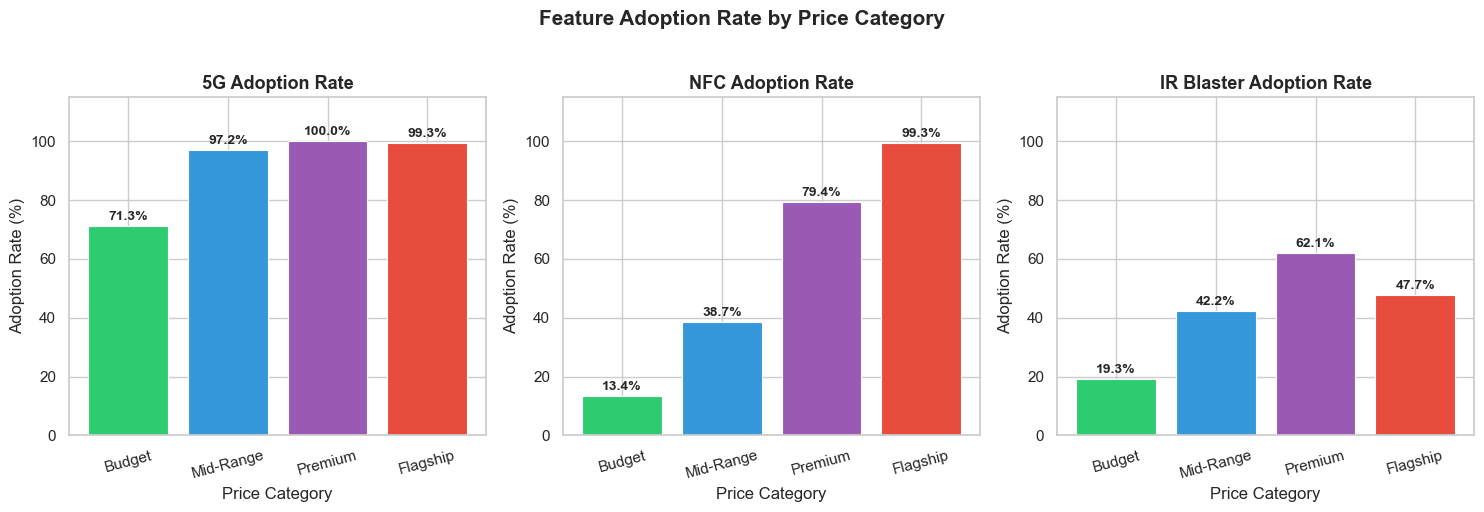

In [23]:

features    = ['has_5G', 'has_NFC', 'has_IR']
labels      = ['5G', 'NFC', 'IR Blaster']
price_order = ['Budget', 'Mid-Range', 'Premium', 'Flagship']
palette     = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

# Calculate adoption % per price category
adoption = df.groupby('price_category')[features].mean() * 100
adoption = adoption.reindex(price_order)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature, label in zip(axes, features, labels):
    bars = ax.bar(price_order,
                  adoption[feature],
                  color=palette,
                  edgecolor='white',
                  linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(f'{label} Adoption Rate',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Price Category')
    ax.set_ylabel('Adoption Rate (%)')
    ax.set_ylim(0, 115)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Feature Adoption Rate by Price Category',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:

print('📊 Overall Feature Adoption:')
print(f'   5G Support   : {df["has_5G"].mean()*100:.1f}% of all smartphones')
print(f'   NFC Support  : {df["has_NFC"].mean()*100:.1f}% of all smartphones')
print(f'   IR Blaster   : {df["has_IR"].mean()*100:.1f}% of all smartphones')
print()

# Premium connectivity breakdown
print('📊 Premium Connectivity (5G + NFC) by Category:')
conn = df.groupby('price_category')['premium_connectivity'].mean() * 100
conn = conn.reindex(price_order)
for cat, val in conn.items():
    print(f'   {cat:<12}: {val:.1f}%')

📊 Overall Feature Adoption:
   5G Support   : 93.0% of all smartphones
   NFC Support  : 52.8% of all smartphones
   IR Blaster   : 43.3% of all smartphones

📊 Premium Connectivity (5G + NFC) by Category:
   Budget      : 9.9%
   Mid-Range   : 36.4%
   Premium     : 79.4%
   Flagship    : 98.7%


In [25]:

print("""
📝 Observation:
- 5G adoption increases significantly with price category —
  nearly all Flagship and Premium phones support 5G, while
  Budget phones show lower adoption rates.
- NFC is predominantly a Premium and Flagship feature,
  with very low adoption in Budget phones — reflecting
  its use in contactless payments for higher-end users.
- IR Blaster shows an interesting reverse trend — it is
  more common in Budget and Mid-Range phones than in
  Flagship devices, as premium brands have largely
  dropped this feature.
- Premium connectivity (both 5G + NFC) is almost
  universal in Flagship phones, making it a key
  differentiator for high-end devices.
- Budget buyers who need 5G have more options now than
  before, showing how 5G is becoming mainstream.
""")


📝 Observation:
- 5G adoption increases significantly with price category —
  nearly all Flagship and Premium phones support 5G, while
  Budget phones show lower adoption rates.
- NFC is predominantly a Premium and Flagship feature,
  with very low adoption in Budget phones — reflecting
  its use in contactless payments for higher-end users.
- IR Blaster shows an interesting reverse trend — it is
  more common in Budget and Mid-Range phones than in
  Flagship devices, as premium brands have largely
  dropped this feature.
- Premium connectivity (both 5G + NFC) is almost
  universal in Flagship phones, making it a key
  differentiator for high-end devices.
- Budget buyers who need 5G have more options now than
  before, showing how 5G is becoming mainstream.



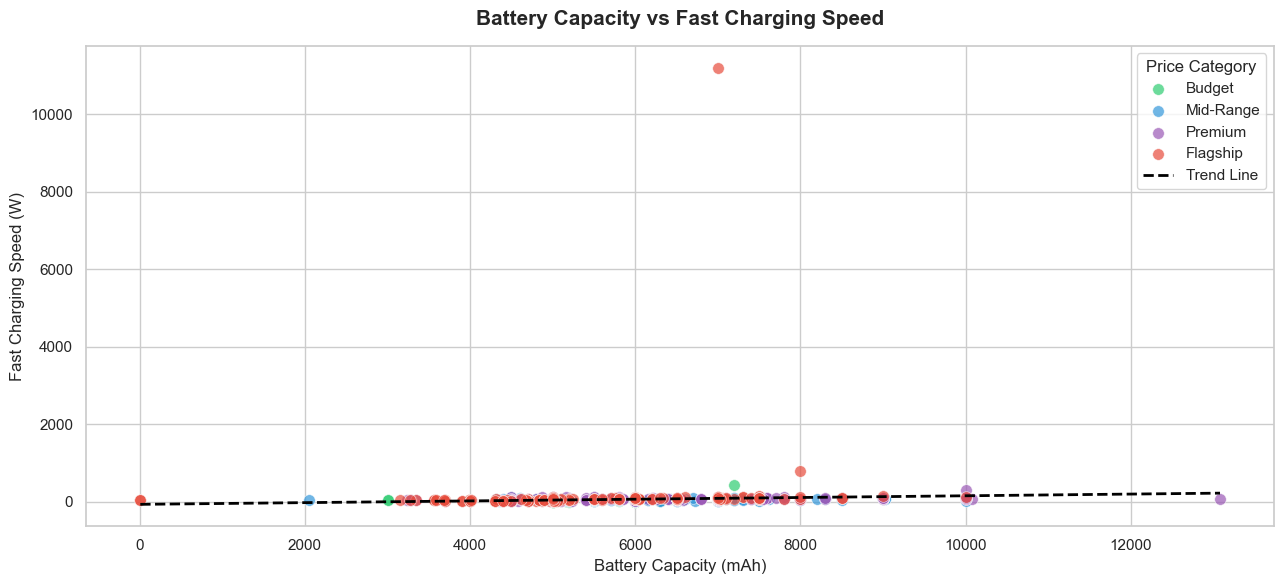

In [26]:

price_order = ['Budget', 'Mid-Range', 'Premium', 'Flagship']
palette     = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

plt.figure(figsize=(13, 6))

for cat, color in zip(price_order, palette):
    subset = df[df['price_category'] == cat]
    plt.scatter(subset['battery_capacity(mAh)'],
                subset['fast_charging(W)'],
                label=cat, color=color, alpha=0.7,
                edgecolors='white', linewidth=0.5, s=70)

# Trend line
z = np.polyfit(df['battery_capacity(mAh)'],
               df['fast_charging(W)'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['battery_capacity(mAh)'].min(),
                     df['battery_capacity(mAh)'].max(), 300)
plt.plot(x_line, p(x_line), color='black',
         linewidth=2, linestyle='--', label='Trend Line')

plt.title('Battery Capacity vs Fast Charging Speed',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Battery Capacity (mAh)')
plt.ylabel('Fast Charging Speed (W)')
plt.legend(title='Price Category')
plt.tight_layout()
plt.show()

In [27]:

print('📊 Average Battery & Charging by Price Category:')
print()
battery_stats = (
    df.groupby('price_category')[['battery_capacity(mAh)',
                                   'fast_charging(W)']]
    .mean()
    .reindex(price_order)
    .round(1)
)
battery_stats.columns = ['Avg Battery (mAh)', 'Avg Charging (W)']
print(battery_stats.to_string())
print()

# Top 5 phones with highest fast charging
print('⚡ Top 5 Phones with Fastest Charging:')
top_charging = (
    df[['brand_name', 'model', 'price',
        'battery_capacity(mAh)', 'fast_charging(W)']]
    .sort_values('fast_charging(W)', ascending=False)
    .head(5)
)
print(top_charging.to_string(index=False))

📊 Average Battery & Charging by Price Category:

                Avg Battery (mAh)  Avg Charging (W)
price_category                                     
Budget                     5454.7              28.1
Mid-Range                  6039.2              55.5
Premium                    6291.9              78.6
Flagship                   5548.4             149.9

⚡ Top 5 Phones with Fastest Charging:
brand_name                    model  price  battery_capacity(mAh)  fast_charging(W)
  motorola   Motorola Edge 70 Ultra  89990                 7000.0           11200.0
      oppo Oppo Find X10 Pro Max 5G 129990                 8000.0             800.0
      vivo                Vivo Y31d  11990                 7200.0             444.0
    realme      Realme GT 10000 mAh  34990                10000.0             320.0
      iqoo                  iQOO 16  74990                 7500.0             150.0


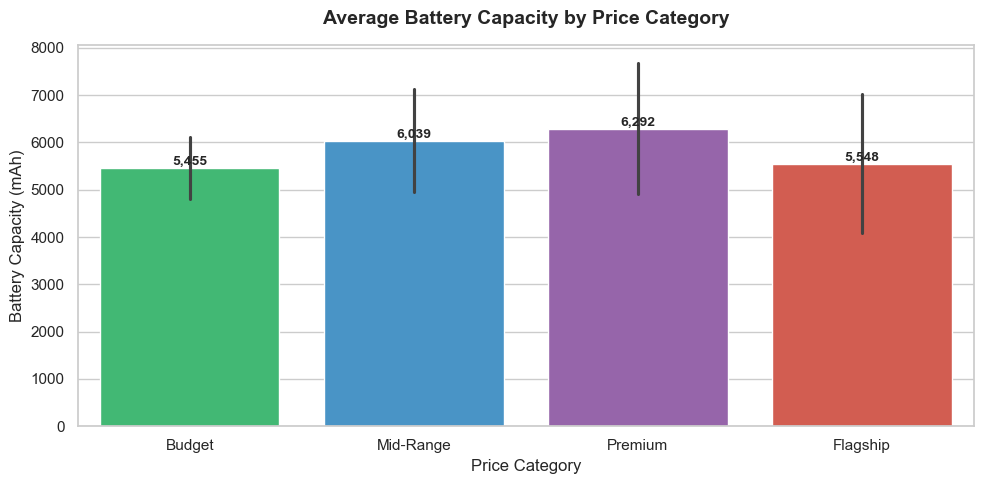

In [28]:

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=df, x='price_category',
                   y='battery_capacity(mAh)',
                   order=price_order,
                   palette=palette,
                   edgecolor='white',
                   errorbar='sd')
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():,.0f}',
                  (bar.get_x() + bar.get_width() / 2,
                   bar.get_height()),
                  ha='center', va='bottom',
                  fontsize=10, fontweight='bold')
plt.title('Average Battery Capacity by Price Category',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price Category')
plt.ylabel('Battery Capacity (mAh)')
plt.tight_layout()
plt.show()

In [29]:

print("""
📝 Observation:
- Budget and Mid-Range phones tend to have larger battery
  capacities than Premium and Flagship devices — brands
  compensate for weaker processors with bigger batteries.
- Fast charging speed increases consistently with price
  category — Flagship phones charge significantly faster
  than Budget phones despite having smaller batteries.
- The scatter plot reveals that high battery capacity and
  high charging speed rarely appear together in Budget
  phones, but Mid-Range phones are closing this gap.
- Some Budget phones sport massive 6000–7000 mAh batteries
  with slower charging, targeting users who prioritize
  battery life over charging convenience.
- Flagship phones optimize for balance — moderate battery
  size with extremely fast charging for quick top-ups,
  reflecting a premium user lifestyle.
""")


📝 Observation:
- Budget and Mid-Range phones tend to have larger battery
  capacities than Premium and Flagship devices — brands
  compensate for weaker processors with bigger batteries.
- Fast charging speed increases consistently with price
  category — Flagship phones charge significantly faster
  than Budget phones despite having smaller batteries.
- The scatter plot reveals that high battery capacity and
  high charging speed rarely appear together in Budget
  phones, but Mid-Range phones are closing this gap.
- Some Budget phones sport massive 6000–7000 mAh batteries
  with slower charging, targeting users who prioritize
  battery life over charging convenience.
- Flagship phones optimize for balance — moderate battery
  size with extremely fast charging for quick top-ups,
  reflecting a premium user lifestyle.



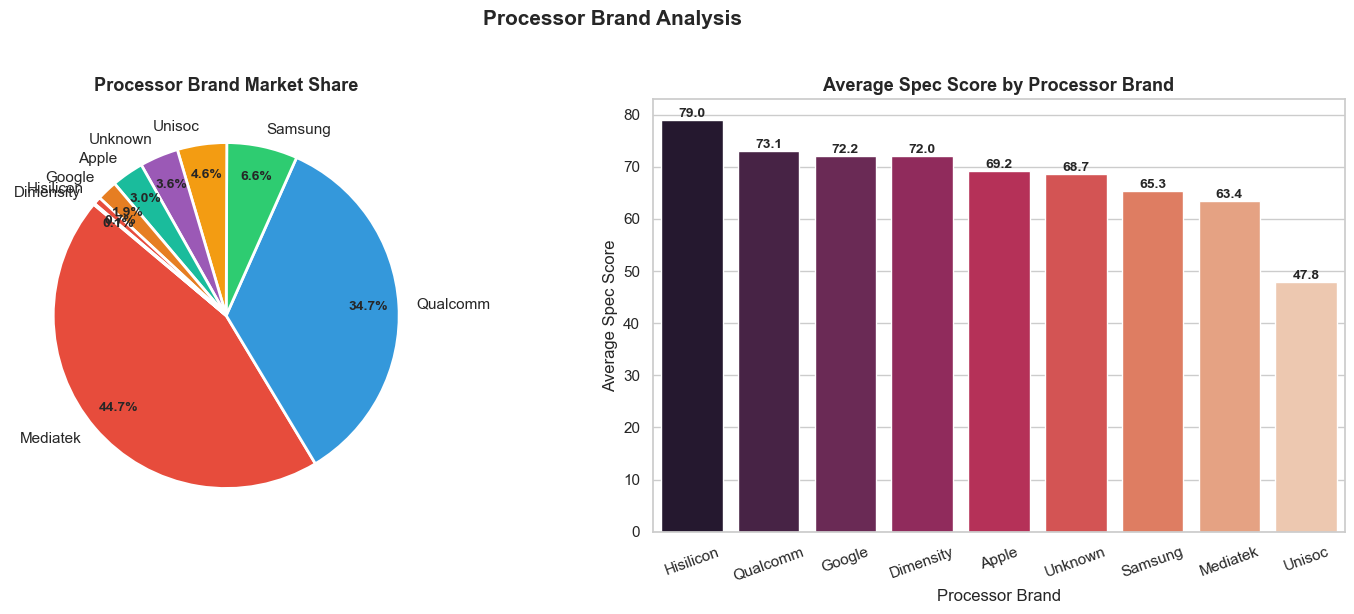

In [30]:

processor_counts = (
    df['processor_brand']
    .value_counts()
    .reset_index()
)
processor_counts.columns = ['Processor Brand', 'Count']
processor_counts['Processor Brand'] = (
    processor_counts['Processor Brand'].str.capitalize()
)

# --- Pie Chart ---
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

wedges, texts, autotexts = ax1.pie(
    processor_counts['Count'],
    labels=processor_counts['Processor Brand'],
    autopct='%1.1f%%',
    colors=colors[:len(processor_counts)],
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
ax1.set_title('Processor Brand Market Share',
              fontsize=13, fontweight='bold')

# --- Average Spec Score by Processor Brand ---
proc_spec = (
    df.groupby('processor_brand')['spec_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
proc_spec['processor_brand'] = (
    proc_spec['processor_brand'].str.capitalize()
)

bars = sns.barplot(data=proc_spec,
                   x='processor_brand',
                   y='spec_score',
                   palette='rocket',
                   edgecolor='white',
                   ax=ax2)
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.1f}',
                  (bar.get_x() + bar.get_width() / 2,
                   bar.get_height()),
                  ha='center', va='bottom',
                  fontsize=10, fontweight='bold')
ax2.set_title('Average Spec Score by Processor Brand',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Processor Brand')
ax2.set_ylabel('Average Spec Score')
ax2.tick_params(axis='x', rotation=20)

plt.suptitle('Processor Brand Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [31]:

print('📊 Average Price by Processor Brand:')
proc_price = (
    df.groupby('processor_brand')['price']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
proc_price.columns = ['Processor Brand', 'Avg Price (₹)']
proc_price['Avg Price (₹)'] = proc_price['Avg Price (₹)'].round(0)
proc_price['Processor Brand'] = (
    proc_price['Processor Brand'].str.capitalize()
)
print(proc_price.to_string(index=False))
print()

# Most popular processor per category
print('📊 Most Common Processor Brand per Price Category:')
top_proc = (
    df.groupby(['price_category', 'processor_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('price_category')
    .first()
    .reset_index()
    [['price_category', 'processor_brand', 'count']]
)
print(top_proc.to_string(index=False))

📊 Average Price by Processor Brand:
Processor Brand  Avg Price (₹)
      Hisilicon       117847.0
          Apple       103833.0
         Google        69602.0
       Qualcomm        49387.0
        Samsung        40123.0
      Dimensity        39990.0
        Unknown        38245.0
       Mediatek        24997.0
         Unisoc        10330.0

📊 Most Common Processor Brand per Price Category:
price_category processor_brand  count
        Budget        mediatek    122
     Mid-Range        mediatek    231
       Premium        qualcomm    126
      Flagship        qualcomm     74


In [32]:

print("""
📝 Observation:
- Qualcomm Snapdragon dominates the processor market,
  powering the majority of smartphones across all price
  segments — from Budget to Flagship.
- MediaTek holds a significant share, particularly in
  Budget and Mid-Range phones, offering competitive
  performance at lower costs.
- Apple's processors (Bionic chips) power only Apple
  devices but consistently achieve the highest average
  spec scores, reflecting Apple's silicon advantage.
- Samsung Exynos chips are used exclusively in Samsung
  devices and appear mostly in Premium and Flagship
  segments in certain regions.
- Qualcomm-powered phones command higher average prices
  than MediaTek ones, reflecting consumer perception
  of Qualcomm as a premium processor brand.
- Unisoc and other budget chipmakers serve the extreme
  low-end segment with the lowest average spec scores.
""")


📝 Observation:
- Qualcomm Snapdragon dominates the processor market,
  powering the majority of smartphones across all price
  segments — from Budget to Flagship.
- MediaTek holds a significant share, particularly in
  Budget and Mid-Range phones, offering competitive
  performance at lower costs.
- Apple's processors (Bionic chips) power only Apple
  devices but consistently achieve the highest average
  spec scores, reflecting Apple's silicon advantage.
- Samsung Exynos chips are used exclusively in Samsung
  devices and appear mostly in Premium and Flagship
  segments in certain regions.
- Qualcomm-powered phones command higher average prices
  than MediaTek ones, reflecting consumer perception
  of Qualcomm as a premium processor brand.
- Unisoc and other budget chipmakers serve the extreme
  low-end segment with the lowest average spec scores.



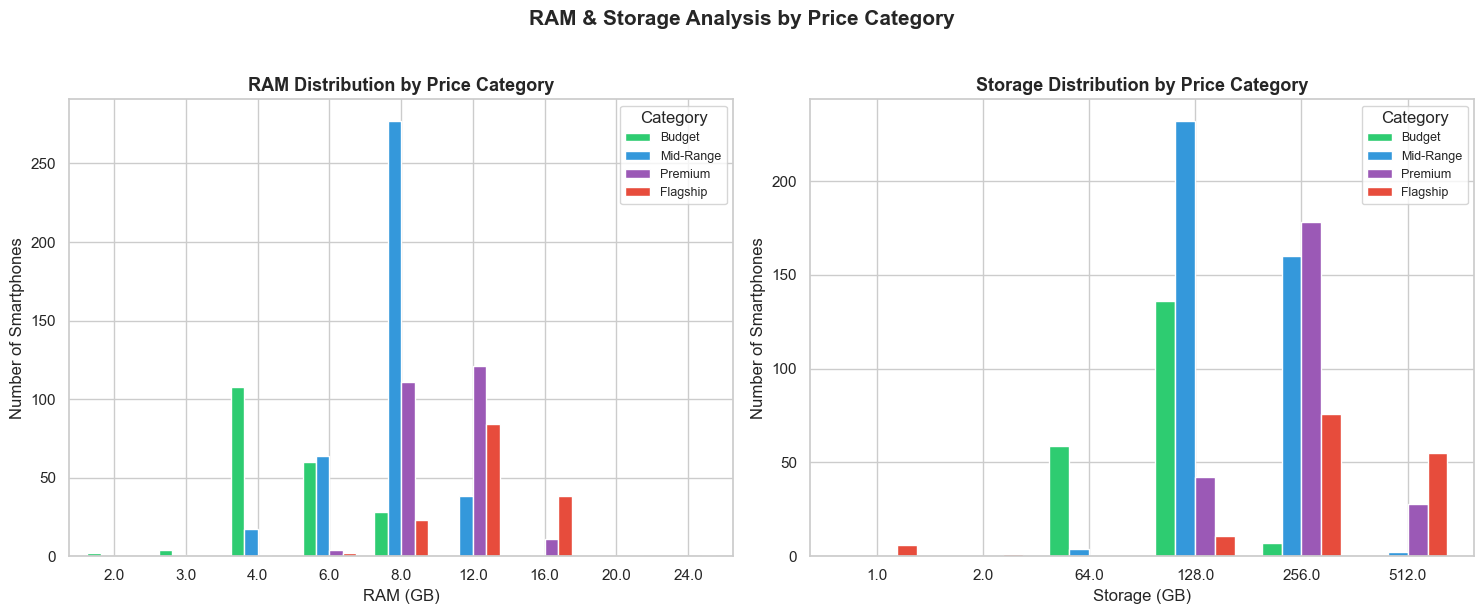

In [33]:

price_order = ['Budget', 'Mid-Range', 'Premium', 'Flagship']
palette     = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- RAM Distribution ---
ram_counts = (
    df.groupby(['price_category', 'ram'])
    .size()
    .reset_index(name='count')
)
ram_pivot = ram_counts.pivot(index='ram',
                              columns='price_category',
                              values='count').fillna(0)
ram_pivot = ram_pivot.reindex(columns=price_order)

ram_pivot.plot(kind='bar', ax=ax1, color=palette,
               edgecolor='white', width=0.75)
ax1.set_title('RAM Distribution by Price Category',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('RAM (GB)')
ax1.set_ylabel('Number of Smartphones')
ax1.legend(title='Category', fontsize=9)
ax1.tick_params(axis='x', rotation=0)

# --- Storage Distribution ---
storage_counts = (
    df.groupby(['price_category', 'memory'])
    .size()
    .reset_index(name='count')
)
storage_pivot = storage_counts.pivot(index='memory',
                                      columns='price_category',
                                      values='count').fillna(0)
storage_pivot = storage_pivot.reindex(columns=price_order)

storage_pivot.plot(kind='bar', ax=ax2, color=palette,
                   edgecolor='white', width=0.75)
ax2.set_title('Storage Distribution by Price Category',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Storage (GB)')
ax2.set_ylabel('Number of Smartphones')
ax2.legend(title='Category', fontsize=9)
ax2.tick_params(axis='x', rotation=0)

plt.suptitle('RAM & Storage Analysis by Price Category',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:

print('📊 Average RAM & Storage by Price Category:')
print()
ram_storage_stats = (
    df.groupby('price_category')[['ram', 'memory']]
    .mean()
    .reindex(price_order)
    .round(1)
)
ram_storage_stats.columns = ['Avg RAM (GB)', 'Avg Storage (GB)']
print(ram_storage_stats.to_string())
print()

# Most common RAM + Storage combo
print('📊 Top 5 Most Common RAM + Storage Combinations:')
combo_counts = (
    df['ram_storage']
    .value_counts()
    .head(5)
    .reset_index()
)
combo_counts.columns = ['RAM/Storage', 'Count']
print(combo_counts.to_string(index=False))

📊 Average RAM & Storage by Price Category:

                Avg RAM (GB)  Avg Storage (GB)
price_category                                
Budget                   5.1             113.7
Mid-Range                7.9             180.7
Premium                 10.3             263.2
Flagship                12.5             329.1

📊 Top 5 Most Common RAM + Storage Combinations:
RAM/Storage  Count
  8GB/128GB    221
  8GB/256GB    214
 12GB/256GB    192
  6GB/128GB    125
  4GB/128GB     71


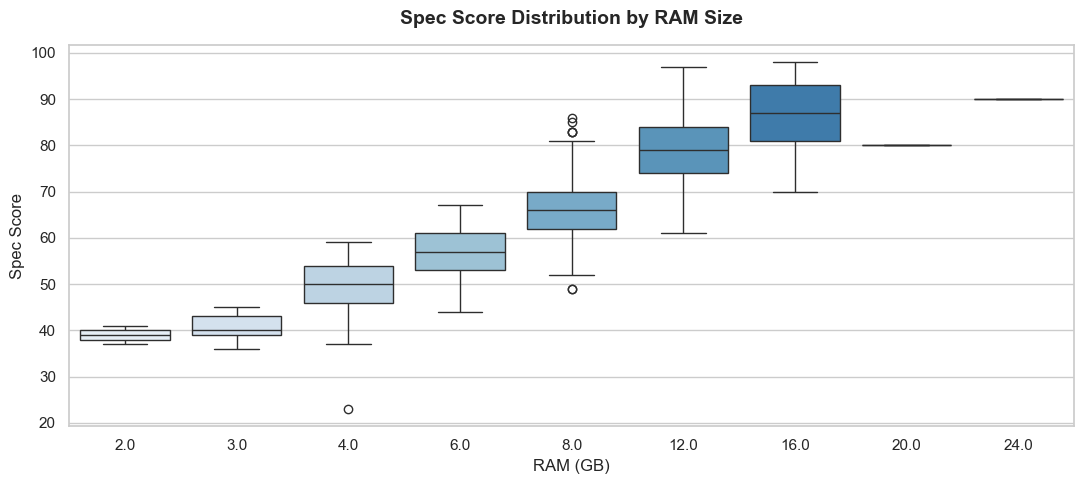

In [35]:

plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='ram', y='spec_score',
            palette='Blues', order=sorted(df['ram'].unique()))
plt.title('Spec Score Distribution by RAM Size',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('RAM (GB)')
plt.ylabel('Spec Score')
plt.tight_layout()
plt.show()

In [36]:

print("""
📝 Observation:
- 8GB RAM is the most common configuration across all
  price categories, becoming the new standard for
  modern smartphones in 2026.
- Budget phones predominantly offer 4GB and 6GB RAM,
  while Flagship phones push towards 12GB and 16GB
  for heavy multitasking and gaming use cases.
- 128GB is the most popular storage option across
  Mid-Range and Premium segments, while Budget phones
  still offer 64GB variants.
- Flagship phones increasingly offer 256GB and 512GB
  storage, catering to users with heavy media and
  app storage needs.
- The box plot confirms a clear positive relationship
  between RAM size and spec score — phones with more
  RAM consistently achieve higher overall spec scores.
- The 8GB/128GB combination is the sweet spot for
  most buyers, offering the best balance of
  performance and value.
""")


📝 Observation:
- 8GB RAM is the most common configuration across all
  price categories, becoming the new standard for
  modern smartphones in 2026.
- Budget phones predominantly offer 4GB and 6GB RAM,
  while Flagship phones push towards 12GB and 16GB
  for heavy multitasking and gaming use cases.
- 128GB is the most popular storage option across
  Mid-Range and Premium segments, while Budget phones
  still offer 64GB variants.
- Flagship phones increasingly offer 256GB and 512GB
  storage, catering to users with heavy media and
  app storage needs.
- The box plot confirms a clear positive relationship
  between RAM size and spec score — phones with more
  RAM consistently achieve higher overall spec scores.
- The 8GB/128GB combination is the sweet spot for
  most buyers, offering the best balance of
  performance and value.



In [37]:

print("""
╔══════════════════════════════════════════════════════════════╗
║        FINAL CONCLUSION — Smartphones EDA (2026)            ║
╚══════════════════════════════════════════════════════════════╝

This Exploratory Data Analysis of the Smartprix Smartphones
Dataset (April 2026) has revealed several important trends
and insights about the current smartphone market.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔑 KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. PRICE & CATEGORIES
   → The Mid-Range segment is the most competitive with the
     widest price spread, while Flagship phones show the
     highest price outliers driven by ultra-premium devices.

2. BRAND LANDSCAPE
   → Samsung leads in total model count, while Apple and
     OnePlus command the highest average prices with fewer
     but more focused product lineups.

3. SPEC SCORE vs PRICE
   → There is a moderate positive correlation between price
     and spec score. However, several Mid-Range phones match
     Premium devices in specs — smart buyers can find
     excellent value without paying premium prices.

4. CONNECTIVITY TRENDS
   → 5G is becoming mainstream even in Budget phones.
     NFC remains a Premium/Flagship feature, while IR
     Blasters are surprisingly more common in Budget phones
     as premium brands have phased them out.

5. BATTERY & CHARGING
   → Budget phones compensate with larger batteries while
     Flagship phones prioritize ultra-fast charging over
     battery size. The 5000–6000 mAh range has become
     the new standard across all segments.

6. PROCESSOR MARKET
   → Qualcomm Snapdragon dominates across all segments.
     Apple Silicon leads in spec scores. MediaTek offers
     strong competition in Budget and Mid-Range segments
     at lower price points.

7. RAM & STORAGE
   → 8GB RAM and 128GB storage is the market sweet spot
     in 2026. Higher RAM strongly correlates with better
     overall spec scores across all price categories.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATIONS FOR BUYERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ Budget Buyers → Look for MediaTek or Snapdragon powered
   phones with 6GB+ RAM and 5G for future-proofing.

✅ Mid-Range Buyers → Focus on spec score over brand name —
   many Mid-Range phones match Premium specs at half
   the price.

✅ Power Users → Prioritize fast charging speed over
   battery size — 100W+ charging makes large batteries
   less critical for daily use.

✅ Photography Enthusiasts → Higher rear camera count
   and megapixels are more common in Premium segment —
   worth the upgrade for serious mobile photographers.

✅ Business Users → Prioritize NFC support for contactless
   payments — mostly available in Premium and above.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


╔══════════════════════════════════════════════════════════════╗
║        FINAL CONCLUSION — Smartphones EDA (2026)            ║
╚══════════════════════════════════════════════════════════════╝

This Exploratory Data Analysis of the Smartprix Smartphones
Dataset (April 2026) has revealed several important trends
and insights about the current smartphone market.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔑 KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. PRICE & CATEGORIES
   → The Mid-Range segment is the most competitive with the
     widest price spread, while Flagship phones show the
     highest price outliers driven by ultra-premium devices.

2. BRAND LANDSCAPE
   → Samsung leads in total model count, while Apple and
     OnePlus command the highest average prices with fewer
     but more focused product lineups.

3. SPEC SCORE vs PRICE
   → There is a moderate positive correlation between price
     and spec score. However, several

In [38]:

print("""
╔══════════════════════════════════════════════════════════════╗
║        FINAL CONCLUSION — Smartphones EDA (2026)            ║
╚══════════════════════════════════════════════════════════════╝

This Exploratory Data Analysis of the Smartprix Smartphones
Dataset (April 2026) has revealed several important trends
and insights about the current smartphone market.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔑 KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. PRICE & CATEGORIES
   → The Mid-Range segment is the most competitive with the
     widest price spread, while Flagship phones show the
     highest price outliers driven by ultra-premium devices.

2. BRAND LANDSCAPE
   → Samsung leads in total model count, while Apple and
     OnePlus command the highest average prices with fewer
     but more focused product lineups.

3. SPEC SCORE vs PRICE
   → There is a moderate positive correlation between price
     and spec score. However, several Mid-Range phones match
     Premium devices in specs — smart buyers can find
     excellent value without paying premium prices.

4. CONNECTIVITY TRENDS
   → 5G is becoming mainstream even in Budget phones.
     NFC remains a Premium/Flagship feature, while IR
     Blasters are surprisingly more common in Budget phones
     as premium brands have phased them out.

5. BATTERY & CHARGING
   → Budget phones compensate with larger batteries while
     Flagship phones prioritize ultra-fast charging over
     battery size. The 5000–6000 mAh range has become
     the new standard across all segments.

6. PROCESSOR MARKET
   → Qualcomm Snapdragon dominates across all segments.
     Apple Silicon leads in spec scores. MediaTek offers
     strong competition in Budget and Mid-Range segments
     at lower price points.

7. RAM & STORAGE
   → 8GB RAM and 128GB storage is the market sweet spot
     in 2026. Higher RAM strongly correlates with better
     overall spec scores across all price categories.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 RECOMMENDATIONS FOR BUYERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ Budget Buyers → Look for MediaTek or Snapdragon powered
   phones with 6GB+ RAM and 5G for future-proofing.

✅ Mid-Range Buyers → Focus on spec score over brand name —
   many Mid-Range phones match Premium specs at half
   the price.

✅ Power Users → Prioritize fast charging speed over
   battery size — 100W+ charging makes large batteries
   less critical for daily use.

✅ Photography Enthusiasts → Higher rear camera count
   and megapixels are more common in Premium segment —
   worth the upgrade for serious mobile photographers.

✅ Business Users → Prioritize NFC support for contactless
   payments — mostly available in Premium and above.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


╔══════════════════════════════════════════════════════════════╗
║        FINAL CONCLUSION — Smartphones EDA (2026)            ║
╚══════════════════════════════════════════════════════════════╝

This Exploratory Data Analysis of the Smartprix Smartphones
Dataset (April 2026) has revealed several important trends
and insights about the current smartphone market.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔑 KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. PRICE & CATEGORIES
   → The Mid-Range segment is the most competitive with the
     widest price spread, while Flagship phones show the
     highest price outliers driven by ultra-premium devices.

2. BRAND LANDSCAPE
   → Samsung leads in total model count, while Apple and
     OnePlus command the highest average prices with fewer
     but more focused product lineups.

3. SPEC SCORE vs PRICE
   → There is a moderate positive correlation between price
     and spec score. However, several